In [12]:
%matplotlib widget

In [13]:
import numpy as np
import pygimli as pg
import empymod as ep
from sklearn.metrics import root_mean_squared_error
import matplotlib.pyplot as plt
import sys
sys.path.insert(1, 'src')

from FDEM1D import FDEM1DModelling_nosort, LCModelling
from showStitched import showStitchedModels
from Plot import grid

In [14]:
# model_true

x = np.linspace(0, 70, 70, endpoint=False)

h_a = x.copy()
h_a[:10] = np.sin(x[10]/10) + 1.5
h_a[10:60] = np.sin(x[10:60]/10) + 1.5
h_a[60:] = np.sin(x[60]/10) + 1.5
h_1 = 3- h_a

s_a = np.ones_like(x) * 1 /1e6
s_1 = np.ones_like(x) * 100/1000
s_2 = np.ones_like(x) * 10/1000

model_topo = np.array([h_a, h_1, s_a, s_1, s_2]).T
model_true = np.array([h_1[:-8], s_1[:-8], s_2[:-8]]).T

In [15]:
#model_true = np.load('model_Topo3D.npy')

In [16]:
# Define a start model
model_ini = np.ones_like(model_true)
model_ini[:,0] = model_ini[:,0]*2   # initial thickness h_1
model_ini[:,1] = model_ini[:,1]*0.05 # initial sigma_1
model_ini[:,2] = model_ini[:,2]*0.05 # initial sigma_2

In [17]:
data_true =  np.load('data_3D_parallel_test3.npy')

In [18]:
len(data_true)

62

In [19]:
#data_Q = data_true[:,:6].copy() #cut out V coil
#data_IP = data_true[:,9:15].copy()
#data_true = np.hstack((data_Q, data_IP))

In [28]:
# number of layers
nLayers = np.shape(model_true)[1] -1

# number of measurement positions 
npos = len(data_true)

LCI = LCModelling(FDEM1DModelling_nosort)

hw = 10
sw = 100

LCI.initJacobian(dataVals=data_true, nLay=nLayers)
LCI.createJacobian(model_ini)
LCI.constraint_matrix(data_true, nLay=nLayers)
LCI.normalization(data_true, cWeight_1=1, cWeight_2=1, nLay=nLayers)
LCI.createWeight(data_true, cWeight_1=hw, cWeight_2=sw, nLay=nLayers)
LCI.createConstraints()

# Set transforms
#transData = pg.trans.TransLog()
transThk = pg.trans.TransLogLU(0.5,3)
transSig = pg.trans.TransLogLU(5/1000, 200/1000)

LCI.region(1).setTransModel(transThk)
LCI.region(2).setTransModel(transSig)

# Create data vector
data_true_vector = data_true.ravel()
relativeError = np.ones_like(data_true_vector)*1e-3 

# Run inversion
inv = pg.Inversion(LCI)
#inv.dataTrans = transData
model_inv = inv.run(data_true_vector, relativeError, startModel=model_ini.ravel(), verbose=False, lam=1)

model_inv = np.array(model_inv).reshape(np.shape(model_true))
data_inv = np.array(inv.response)
data_inv = data_inv.reshape(np.shape(data_true))

Inversion is normalized
Jacobian size: 1098 183 1116


14/11/24 - 16:42:37 - Core - WARNING - no clear() implemented for:  18MatrixBase_wrapper
14/11/24 - 16:42:37 - Core - ERROR - no cWeights defined. You should create constraints matrix first.


cWeights are equal
Constraint cWeight length: 183
CW:  <pygimli.math.matrix.MultLeftMatrix object at 0x7f7f78a7b150>


In [29]:
model_inv = np.array(model_inv)
model_inv_topo = np.array([h_a[:-8], model_inv[:,0], s_a[:-8], model_inv[:,1], model_inv[:,2]]).T

In [30]:
model_h_rmse = root_mean_squared_error(model_true[:,0].ravel(), model_inv[:,0].ravel())
model_s_rmse = root_mean_squared_error(model_true[:,1:].ravel(), model_inv[:,1:].ravel())*1000
data_rmse = root_mean_squared_error(data_true.ravel(), data_inv.ravel())*1000

(-4.0, 0.0)

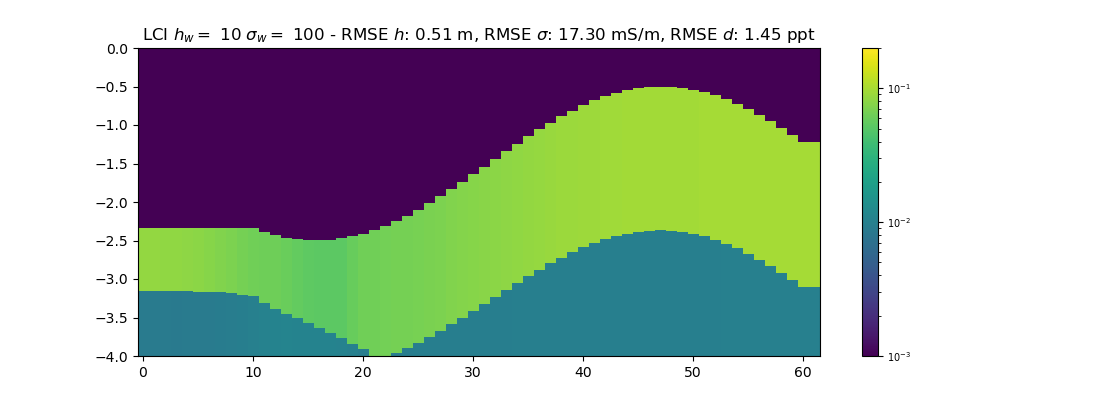

In [31]:
fig, ax = plt.subplots(figsize=(11,4))
showStitchedModels(model_inv_topo,  zMax=4, cMin=1/1000, cMax=0.2, ax=ax)
ax.set_title(f'LCI $h_w = $ {hw} $\sigma_w = $ {sw} - RMSE $h$: {model_h_rmse:.2f} m, RMSE $\sigma$: {model_s_rmse:.2f} mS/m, RMSE $d$: {data_rmse:.2f} ppt')
ax.set_ylim([-4, 0])

(-4.0, 0.0)

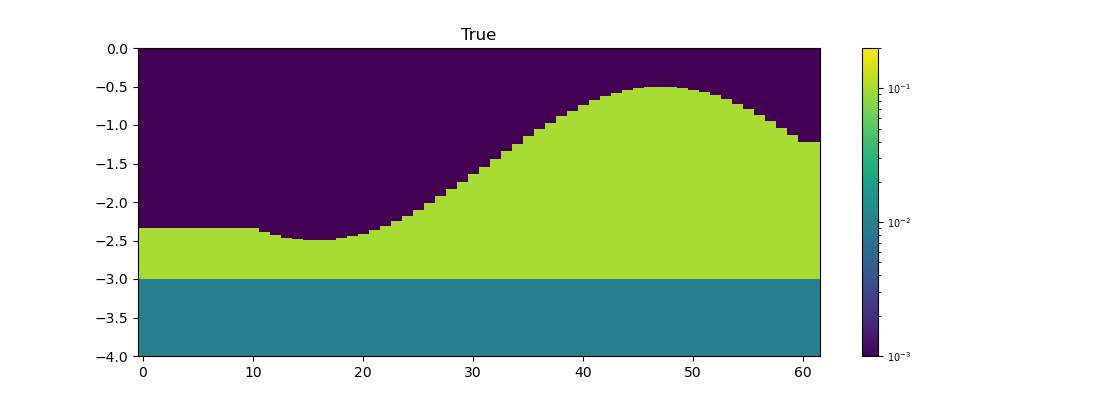

In [32]:
fig, ax = plt.subplots(figsize=(11,4))
showStitchedModels(model_topo[:62], zMax=4,cMin=1/1000, cMax=0.2, ax=ax)
ax.set_title('True')
ax.set_ylim([-4, 0])

In [33]:
model_true_g = grid(model_topo[:62], depthmax=4, nlay=3)
model_inv_g = grid(model_inv_topo, depthmax=4, nlay=3)

diff_g = np.abs(model_true_g - model_inv_g)*1000

(-4.0, 0.0)

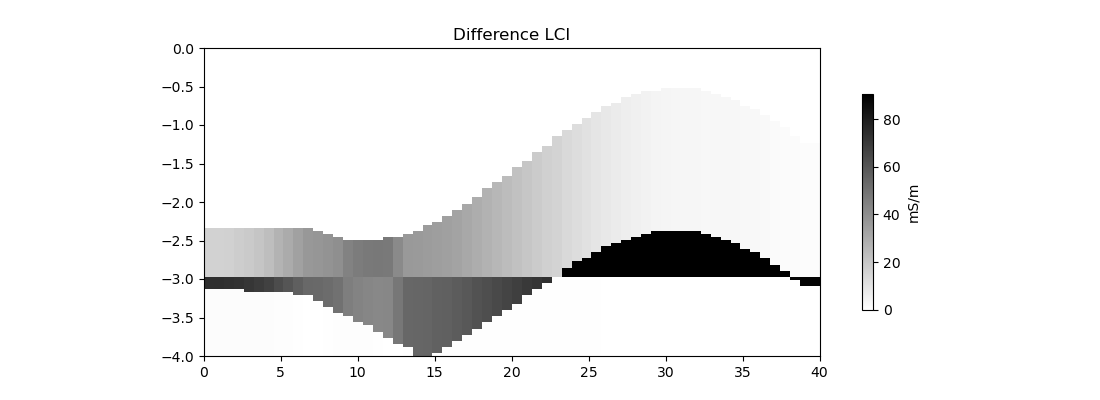

In [34]:
fig, ax = plt.subplots(figsize=(11,4))

c = ax.imshow(diff_g.T, extent = [0,40, -4, 0], aspect=5, cmap='binary')
fig.colorbar(c, label='mS/m', shrink=0.7)
ax.set_title('Difference LCI')
ax.set_ylim([-4, 0])

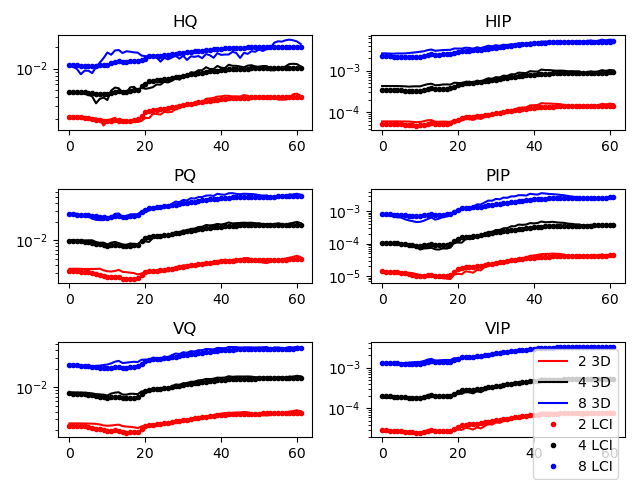

In [35]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(3,2)

ax[0,0].semilogy(data_true[:,0], 'r', label='2')
ax[0,0].semilogy(data_true[:,1], 'k', label='4')
ax[0,0].semilogy(data_true[:,2], 'b', label='8')
ax[0,0].semilogy(data_inv[:,0], '.r', label='2')
ax[0,0].semilogy(data_inv[:,1], '.k', label='4')
ax[0,0].semilogy(data_inv[:,2], '.b', label='8')

ax[0,0].set_title('HQ')
#ax[0,0].legend()

ax[1,0].semilogy(data_true[:,3], 'r', label='2')
ax[1,0].semilogy(data_true[:,4], 'k', label='4')
ax[1,0].semilogy(data_true[:,5], 'b', label='8')
ax[1,0].semilogy(data_inv[:,3], '.r', label='2')
ax[1,0].semilogy(data_inv[:,4], '.k', label='4')
ax[1,0].semilogy(data_inv[:,5], '.b', label='8')
ax[1,0].set_title('PQ')
#ax[1,0].legend()

ax[2,0].semilogy(data_true[:,6], 'r', label='2')
ax[2,0].semilogy(data_true[:,7], 'k', label='4')
ax[2,0].semilogy(data_true[:,8], 'b', label='8')
ax[2,0].semilogy(data_inv[:,6], '.r', label='2')
ax[2,0].semilogy(data_inv[:,7], '.k', label='4')
ax[2,0].semilogy(data_inv[:,8], '.b', label='8')
ax[2,0].set_title('VQ')
#ax[2,0].legend()

ax[0,1].semilogy(data_true[:,9], 'r', label='2')
ax[0,1].semilogy(data_true[:,10], 'k', label='4')
ax[0,1].semilogy(data_true[:,11], 'b', label='8')
ax[0,1].semilogy(data_inv[:,9], '.r', label='2')
ax[0,1].semilogy(data_inv[:,10], '.k', label='4')
ax[0,1].semilogy(data_inv[:,11], '.b', label='8')
ax[0,1].set_title('HIP')

ax[1,1].semilogy(data_true[:,12], 'r', label='2')
ax[1,1].semilogy(data_true[:,13], 'k', label='4')
ax[1,1].semilogy(data_true[:,14], 'b', label='8')
ax[1,1].semilogy(data_inv[:,12], '.r', label='2')
ax[1,1].semilogy(data_inv[:,13], '.k', label='4')
ax[1,1].semilogy(data_inv[:,14], '.b', label='8')
ax[1,1].set_title('PIP')
#ax[2,0].legend()

ax[2,1].semilogy(data_true[:,15], 'r', label='2 3D')
ax[2,1].semilogy(data_true[:,16], 'k', label='4 3D')
ax[2,1].semilogy(data_true[:,17], 'b', label='8 3D')
ax[2,1].semilogy(data_inv[:,15], '.r', label='2 LCI')
ax[2,1].semilogy(data_inv[:,16], '.k', label='4 LCI')
ax[2,1].semilogy(data_inv[:,17], '.b', label='8 LCI')
ax[2,1].set_title('VIP')
ax[2,1].legend()

plt.tight_layout()